# Step 9B — Labeling Otomatis Sentimen

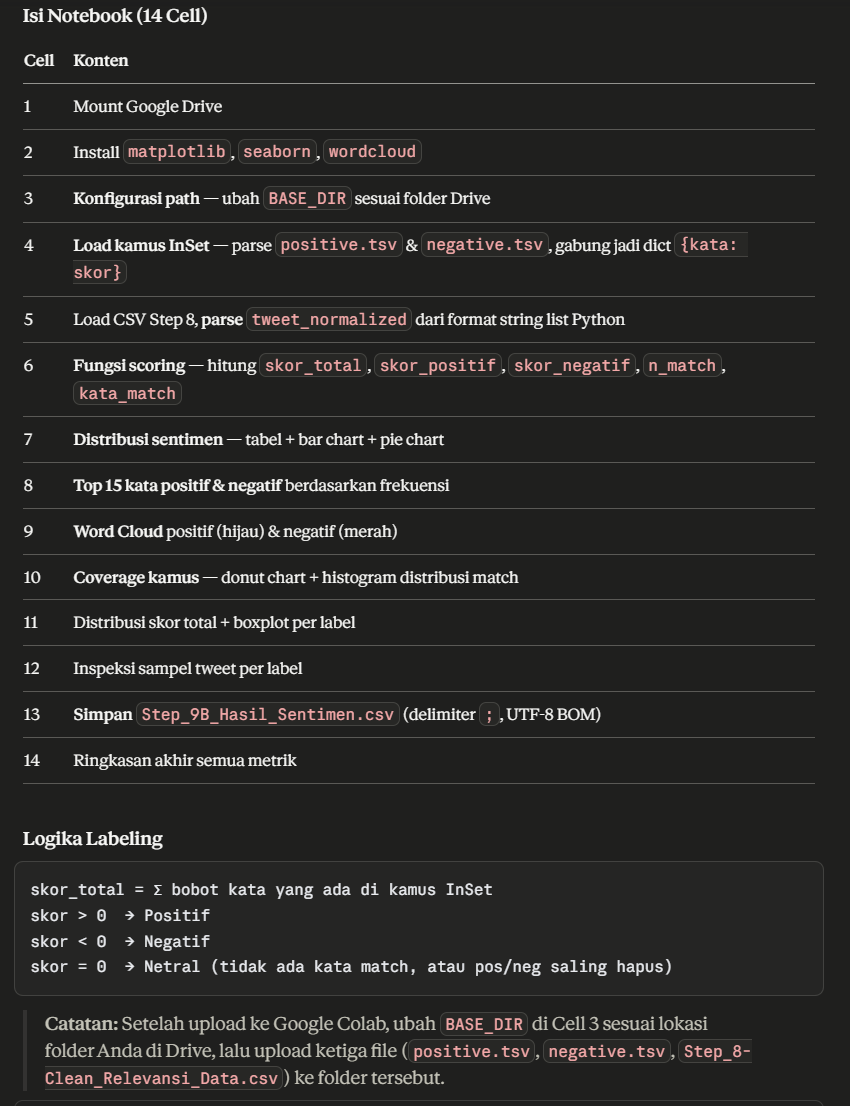

> **Kamus:** InSet Lexicon — `positive.tsv` (3.609 kata) & `negative.tsv` (6.609 kata)  
> **Input:** `Step_8-Clean_Relevansi_Data.csv` → kolom `tweet_normalized`  
> **Output label:** `Positif` / `Negatif` / `Netral` berdasarkan total skor bobot  
> **Analisis:** distribusi sentimen, top kata positif/negatif, coverage kamus

---
### Alur Kerja
```
Step 8 CSV  ──►  parse tweet_normalized  ──►  lookup InSet  ──►  hitung skor
                                                                      │
                                            ┌─────────────────────────┤
                                          skor>0   skor<0    skor==0
                                         Positif  Negatif   Netral
                                            └─────────────────────────┘
                                                      │
                                          Step_9B_Hasil_Sentimen.csv
```

## 1. Mount Google Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install dependensi tambahan jika dibutuhkan
!pip install matplotlib seaborn wordcloud --quiet

## 2. Konfigurasi Path File

Sesuaikan path sesuai lokasi file di Google Drive Anda.

In [ ]:
# ============================================================
# KONFIGURASI PATH — sesuaikan dengan lokasi file Anda
# ============================================================
import os

BASE_DIR = '/content'  # <-- ubah sesuai folder Anda

PATH_INPUT_CSV   = os.path.join(BASE_DIR, 'Step_8-Clean_Relevansi_Data.csv')
PATH_POSITIVE_TSV = os.path.join(BASE_DIR, 'positive.tsv')
PATH_NEGATIVE_TSV = os.path.join(BASE_DIR, 'negative.tsv')
PATH_OUTPUT_CSV  = os.path.join(BASE_DIR, 'Step_9B_Hasil_Sentimen.csv')

# Validasi file tersedia
for label, path in [
    ('Input CSV',     PATH_INPUT_CSV),
    ('Positive TSV',  PATH_POSITIVE_TSV),
    ('Negative TSV',  PATH_NEGATIVE_TSV),
]:
    status = '✅' if os.path.exists(path) else '❌ TIDAK DITEMUKAN'
    print(f"{status}  {label}: {path}")

✅  Input CSV: /content/Step_8-Clean_Relevansi_Data.csv
✅  Positive TSV: /content/positive.tsv
✅  Negative TSV: /content/negative.tsv


## 3. Import Library

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

# Styling konsisten
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#95a5a6'}

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 4. Load Kamus InSet

In [ ]:
def load_inset_lexicon(pos_path: str, neg_path: str) -> dict:
    """
    Membaca kamus InSet dan menggabungkan menjadi dict {kata: skor}.
    Positif: skor 1..5, Negatif: skor -5..-1
    Jika kata ada di kedua kamus, ambil nilai dengan absolut terbesar.
    """
    def _read_tsv(path):
        df = pd.read_csv(path, sep='\t', header=0, names=['word', 'weight'])
        # Bersihkan spasi berlebih pada kata
        df['word'] = df['word'].str.strip().str.lower()
        df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
        return df.dropna(subset=['weight'])

    pos_df = _read_tsv(pos_path)
    neg_df = _read_tsv(neg_path)

    lexicon = {}
    for _, row in pos_df.iterrows():
        lexicon[row['word']] = float(row['weight'])
    for _, row in neg_df.iterrows():
        w = row['word']
        score = float(row['weight'])
        if w not in lexicon or abs(score) > abs(lexicon[w]):
            lexicon[w] = score

    return lexicon


lexicon = load_inset_lexicon(PATH_POSITIVE_TSV, PATH_NEGATIVE_TSV)

pos_words = {k: v for k, v in lexicon.items() if v > 0}
neg_words = {k: v for k, v in lexicon.items() if v < 0}

print(f'📖 Total entri kamus    : {len(lexicon):,}')
print(f'   ✅ Kata positif      : {len(pos_words):,}')
print(f'   ❌ Kata negatif      : {len(neg_words):,}')
print()
print('Contoh kata positif:', list(pos_words.items())[:5])
print('Contoh kata negatif:', list(neg_words.items())[:5])

📖 Total entri kamus    : 9,071
   ✅ Kata positif      : 3,053
   ❌ Kata negatif      : 6,018

Contoh kata positif: [('hai', 3.0), ('merekam', 2.0), ('ekstensif', 3.0), ('paripurna', 1.0), ('detail', 2.0)]
Contoh kata negatif: [('belas', -3.0), ('kabung', -5.0), ('maaf', -3.0), ('bentang', -3.0), ('penerangan', -3.0)]


## 5. Load & Parsing Data Tweet

In [ ]:
df = pd.read_csv(PATH_INPUT_CSV, sep=';', encoding='utf-8-sig')

print(f'📊 Jumlah baris data: {len(df)}')
print(f'📋 Kolom tersedia   : {df.columns.tolist()}')
print(f'\nContoh tweet_normalized (raw):')
print(df['tweet_normalized'].iloc[0])

📊 Jumlah baris data: 451
📋 Kolom tersedia   : ['No', 'full_text', 'username', 'tweet_tokens', 'tweet_tokens_fdist', 'tweet_tokens_WSW', 'tweet_normalized', 'tweet_tokens_stemmed', 'Relevansi', 'Cek Konfirmasi Relevansi', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Contoh tweet_normalized (raw):
['anggaran', 'segitu', 'sekolah', 'tambahan', 'orang', 'tua', 'program', 'makan', 'siang', 'gratis', 'mark', 'atas', 'aku', 'sd', 'program', 'snack', 'bergizi', 'gratis', 'program', 'gabungan', 'pkk']


In [ ]:
def parse_token_list(raw) -> list:
    """
    Mengubah string representasi list Python menjadi list kata.
    Menangani format: "['kata1', 'kata2', ...]" atau string biasa.
    """
    if pd.isna(raw):
        return []
    raw = str(raw).strip()

    # Format Python list string
    if raw.startswith('['):
        try:
            tokens = ast.literal_eval(raw)
            return [str(t).strip().lower() for t in tokens if str(t).strip()]
        except (ValueError, SyntaxError):
            # Fallback: ekstrak kata dalam kutipan
            return [m.lower() for m in re.findall(r"['\"]([^'\"]+)['\"]", raw)]

    # Format string biasa — split whitespace
    return [w.lower() for w in raw.split() if w]


df['tokens'] = df['tweet_normalized'].apply(parse_token_list)

# Verifikasi
print('Contoh tokens yang diparsing:')
for i in range(3):
    print(f'  Tweet {i+1}: {df["tokens"].iloc[i][:10]} ...')

print(f'\nTotal tweet berhasil diparsing: {df["tokens"].apply(bool).sum()}/{len(df)}')

Contoh tokens yang diparsing:
  Tweet 1: ['anggaran', 'segitu', 'sekolah', 'tambahan', 'orang', 'tua', 'program', 'makan', 'siang', 'gratis'] ...
  Tweet 2: ['keren', 'program', 'makan', 'siang', 'gratis', 'seperti', 'gini', 'pertumbuhan', 'perkembangan', 'anak'] ...
  Tweet 3: ['prabowo', 'komitmen', 'nyata', 'makan', 'siang', 'gratis', 'bergizi', 'anakanak', 'sekolah'] ...

Total tweet berhasil diparsing: 451/451


## 6. Fungsi Scoring & Labeling Sentimen

In [ ]:
def score_tweet(tokens: list, lexicon: dict) -> dict:
    """
    Menghitung skor sentimen sebuah tweet berdasarkan kamus InSet.

    Mengembalikan:
    {
        'skor_total'   : float  — jumlah semua skor kata ditemukan,
        'skor_positif' : float  — jumlah skor kata positif saja,
        'skor_negatif' : float  — jumlah skor kata negatif saja (nilai negatif),
        'n_match'      : int    — jumlah token yang cocok di kamus,
        'n_total'      : int    — total token dalam tweet,
        'kata_match'   : list   — pasangan (kata, skor) yang cocok,
        'label'        : str    — 'Positif' / 'Negatif' / 'Netral',
    }
    """
    skor_total = 0.0
    skor_pos   = 0.0
    skor_neg   = 0.0
    kata_match = []

    for token in tokens:
        if token in lexicon:
            s = lexicon[token]
            skor_total += s
            kata_match.append((token, s))
            if s > 0:
                skor_pos += s
            else:
                skor_neg += s

    if skor_total > 0:
        label = 'Positif'
    elif skor_total < 0:
        label = 'Negatif'
    else:
        label = 'Netral'

    return {
        'skor_total'   : skor_total,
        'skor_positif' : skor_pos,
        'skor_negatif' : skor_neg,
        'n_match'      : len(kata_match),
        'n_total'      : len(tokens),
        'kata_match'   : kata_match,
        'label'        : label,
    }


# Terapkan ke seluruh dataset
results = df['tokens'].apply(lambda t: score_tweet(t, lexicon))

df['sentimen']     = results.apply(lambda r: r['label'])
df['skor_total']   = results.apply(lambda r: r['skor_total'])
df['skor_positif'] = results.apply(lambda r: r['skor_positif'])
df['skor_negatif'] = results.apply(lambda r: r['skor_negatif'])
df['n_match']      = results.apply(lambda r: r['n_match'])
df['n_total']      = results.apply(lambda r: r['n_total'])
df['kata_match']   = results.apply(lambda r: r['kata_match'])

print('✅ Scoring selesai!')
print(df[['tweet_normalized', 'skor_total', 'skor_positif', 'skor_negatif', 'n_match', 'sentimen']].head(5))

✅ Scoring selesai!
                                    tweet_normalized  skor_total  \
0  ['anggaran', 'segitu', 'sekolah', 'tambahan', ...         3.0   
1  ['keren', 'program', 'makan', 'siang', 'gratis...         4.0   
2  ['prabowo', 'komitmen', 'nyata', 'makan', 'sia...        12.0   
3  ['program', 'prabowo', 'makan', 'gratis', 'kpd...        24.0   
4  ['makanan', 'gratis', 'bergizi', 'ibuibu', 'ha...         0.0   

   skor_positif  skor_negatif  n_match sentimen  
0          19.0         -16.0       10  Positif  
1          12.0          -8.0        7  Positif  
2          12.0           0.0        4  Positif  
3          35.0         -11.0       20  Positif  
4          14.0         -14.0        9   Netral  


## 7. Distribusi Sentimen

In [ ]:
dist = df['sentimen'].value_counts().reindex(['Positif', 'Negatif', 'Netral'], fill_value=0)
dist_pct = (dist / dist.sum() * 100).round(2)

dist_df = pd.DataFrame({
    'Jumlah Tweet': dist,
    'Persentase (%)': dist_pct
})

print('=' * 40)
print('   DISTRIBUSI LABEL SENTIMEN')
print('=' * 40)
print(dist_df.to_string())
print('-' * 40)
print(f'TOTAL: {dist.sum()} tweet')

   DISTRIBUSI LABEL SENTIMEN
          Jumlah Tweet  Persentase (%)
sentimen                              
Positif            352           78.05
Negatif             89           19.73
Netral              10            2.22
----------------------------------------
TOTAL: 451 tweet


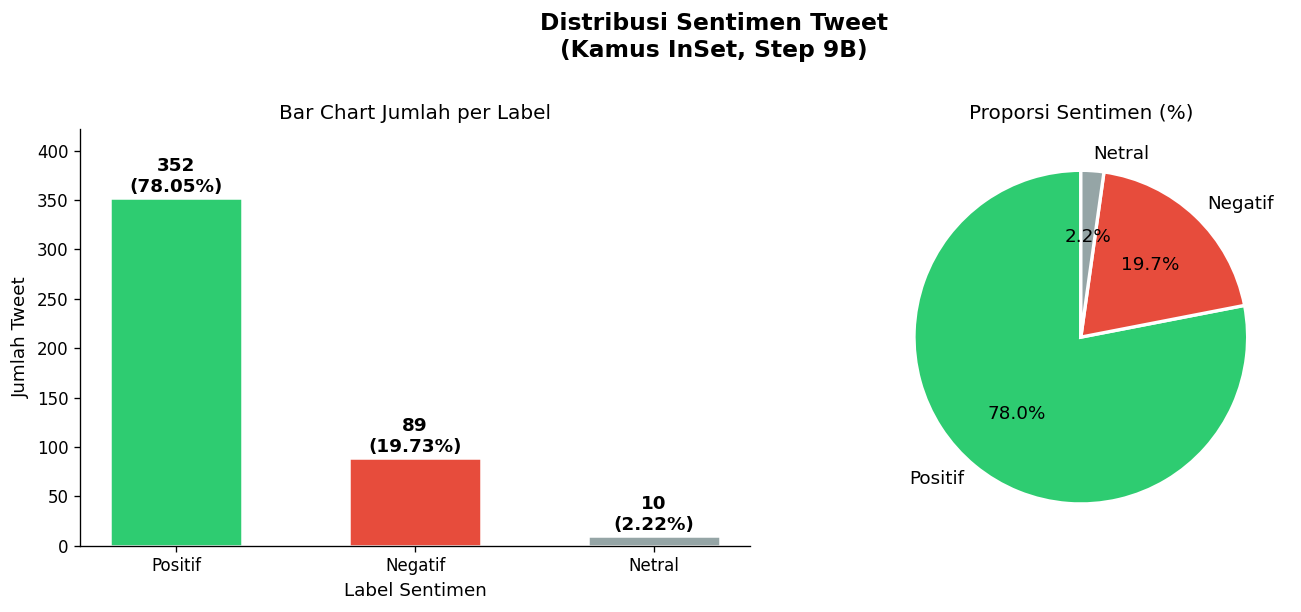

💾 Chart disimpan: Step_9B_distribusi_sentimen.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Sentimen Tweet\n(Kamus InSet)', fontsize=14, fontweight='bold', y=1.01)

# ── Bar chart ──
colors = [PALETTE[s] for s in dist.index]
bars = axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar, cnt, pct in zip(bars, dist.values, dist_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{cnt}\n({pct}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_xlabel('Label Sentimen', fontsize=11)
axes[0].set_ylabel('Jumlah Tweet', fontsize=11)
axes[0].set_title('Bar Chart Jumlah per Label', fontsize=12)
axes[0].set_ylim(0, dist.max() * 1.2)

# ── Pie chart ──
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1].pie(
    dist.values,
    labels=dist.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi Sentimen (%)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Step_9B_distribusi_sentimen.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Chart disimpan: Step_9B_distribusi_sentimen.png')

## 8. Top Kata Positif & Negatif

In [ ]:
TOP_N = 15

# Kumpulkan semua kata yang match beserta skornya
all_pos_hits = Counter()
all_neg_hits = Counter()

for matches in df['kata_match']:
    for kata, skor in matches:
        if skor > 0:
            all_pos_hits[kata] += 1
        elif skor < 0:
            all_neg_hits[kata] += 1

top_pos = pd.DataFrame(all_pos_hits.most_common(TOP_N), columns=['kata', 'frekuensi'])
top_pos['skor'] = top_pos['kata'].map(lexicon)

top_neg = pd.DataFrame(all_neg_hits.most_common(TOP_N), columns=['kata', 'frekuensi'])
top_neg['skor'] = top_neg['kata'].map(lexicon)

print(f'Top {TOP_N} Kata POSITIF yang paling sering muncul:')
print(top_pos.to_string(index=False))
print()
print(f'Top {TOP_N} Kata NEGATIF yang paling sering muncul:')
print(top_neg.to_string(index=False))

Top 15 Kata POSITIF yang paling sering muncul:
    kata  frekuensi  skor
   makan        499   1.0
  gratis        468   4.0
 sekolah         57   3.0
 makanan         51   3.0
   siswa         45   3.0
presiden         43   3.0
   sehat         34   4.0
   nyata         32   4.0
  dukung         29   4.0
kualitas         26   4.0
 manfaat         25   5.0
penerima         22   2.0
 belajar         21   3.0
langsung         19   3.0
   kerja         19   2.0

Top 15 Kata NEGATIF yang paling sering muncul:
       kata  frekuensi  skor
       anak         78  -3.0
   generasi         36  -3.0
      badan         29  -3.0
pelaksanaan         23  -4.0
      salah         15  -4.0
       kuat         14  -3.0
       susu         13  -4.0
      hamil         12  -5.0
     korban         12  -4.0
    standar         12  -2.0
     dampak         12  -3.0
      bahan         10  -3.0
      tidak         10  -5.0
      beban         10  -5.0
    seperti          9  -1.0


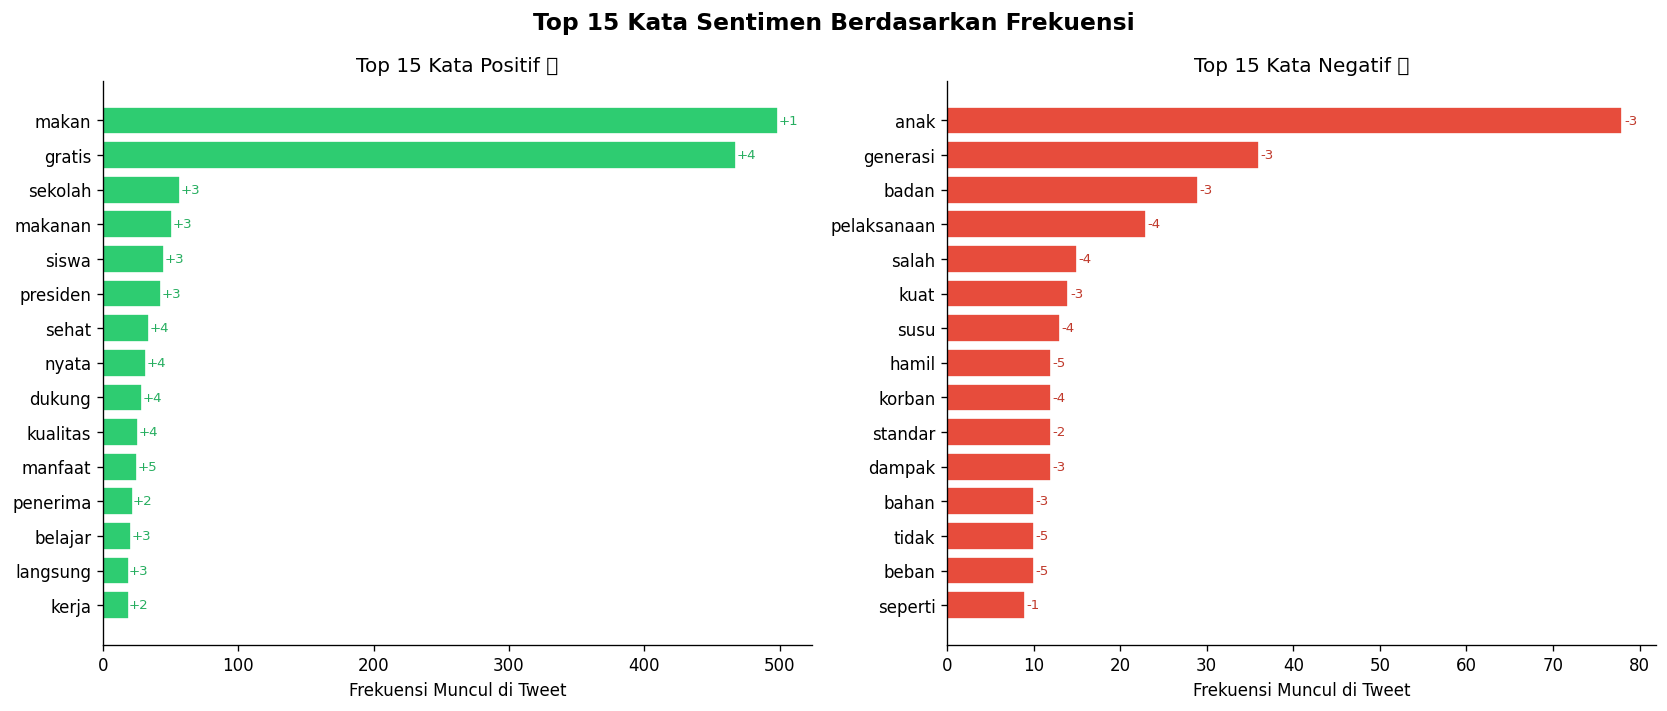

💾 Chart disimpan: Step_9B_top_kata_sentimen.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Top {TOP_N} Kata Sentimen Berdasarkan Frekuensi', fontsize=14, fontweight='bold')

# Positif
axes[0].barh(
    top_pos['kata'][::-1], top_pos['frekuensi'][::-1],
    color=PALETTE['Positif'], edgecolor='white'
)
axes[0].set_title(f'Top {TOP_N} Kata Positif ✅', fontsize=12)
axes[0].set_xlabel('Frekuensi Muncul di Tweet')
for i, (freq, skor) in enumerate(zip(top_pos['frekuensi'][::-1], top_pos['skor'][::-1])):
    axes[0].text(freq + 0.2, i, f'+{skor:.0f}', va='center', fontsize=8, color='#27ae60')

# Negatif
axes[1].barh(
    top_neg['kata'][::-1], top_neg['frekuensi'][::-1],
    color=PALETTE['Negatif'], edgecolor='white'
)
axes[1].set_title(f'Top {TOP_N} Kata Negatif ❌', fontsize=12)
axes[1].set_xlabel('Frekuensi Muncul di Tweet')
for i, (freq, skor) in enumerate(zip(top_neg['frekuensi'][::-1], top_neg['skor'][::-1])):
    axes[1].text(freq + 0.2, i, f'{skor:.0f}', va='center', fontsize=8, color='#c0392b')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Step_9B_top_kata_sentimen.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Chart disimpan: Step_9B_top_kata_sentimen.png')

## 9. Word Cloud Positif & Negatif

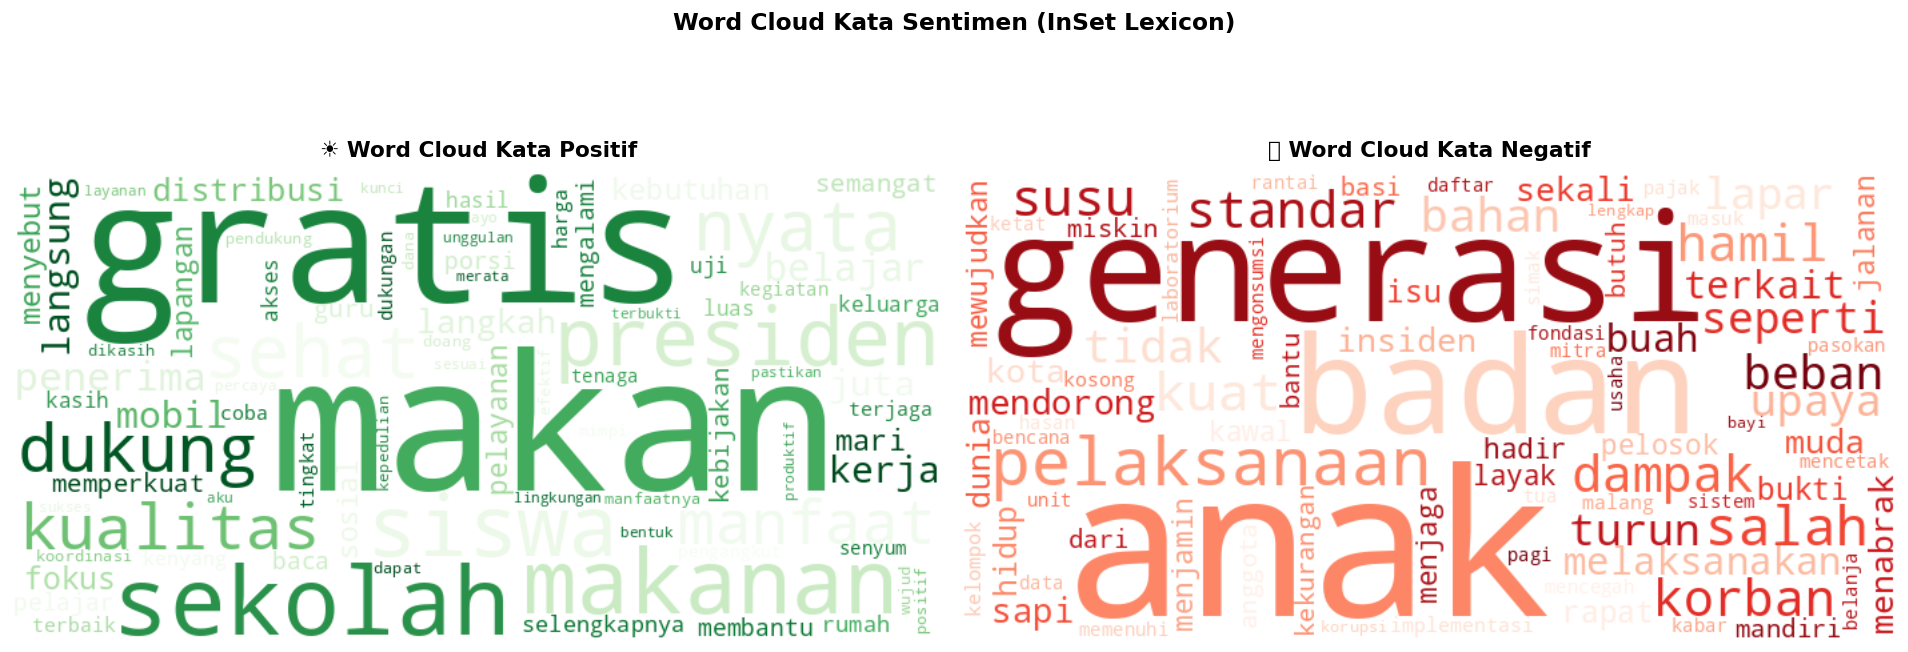

💾 WordCloud disimpan: Step_9B_wordcloud.png


In [ ]:
def make_wordcloud(counter: Counter, colormap: str, title: str, ax):
    if not counter:
        ax.text(0.5, 0.5, 'Tidak ada kata', ha='center', va='center', fontsize=14)
        ax.set_title(title)
        ax.axis('off')
        return
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=colormap,
        max_words=80,
        prefer_horizontal=0.85
    ).generate_from_frequencies(counter)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_wordcloud(all_pos_hits, 'Greens',  '☀️ Word Cloud Kata Positif', axes[0])
make_wordcloud(all_neg_hits, 'Reds',    '🌧️ Word Cloud Kata Negatif', axes[1])

plt.suptitle('Word Cloud Kata Sentimen (InSet Lexicon)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Step_9B_wordcloud.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 WordCloud disimpan: Step_9B_wordcloud.png')

## 10. Analisis Coverage Kamus

In [ ]:
# Coverage = tweet yang memiliki ≥1 kata dari kamus
tweet_covered    = (df['n_match'] > 0).sum()
tweet_not_covered = (df['n_match'] == 0).sum()
coverage_rate    = tweet_covered / len(df) * 100

# Rata-rata match per tweet
avg_match  = df['n_match'].mean()
avg_tokens = df['n_total'].mean()
avg_ratio  = (df['n_match'] / df['n_total'].replace(0, np.nan)).mean() * 100

# Kata unik yang ditemukan di kamus
all_matched_words = set()
for matches in df['kata_match']:
    for kata, _ in matches:
        all_matched_words.add(kata)

print('=' * 50)
print('        ANALISIS COVERAGE KAMUS')
print('=' * 50)
print(f'  Total tweet dianalisis   : {len(df)}')
print(f'  Tweet ≥1 kata match      : {tweet_covered} ({coverage_rate:.1f}%)')
print(f'  Tweet tidak ada match    : {tweet_not_covered} ({100-coverage_rate:.1f}%)')
print(f'  Rata-rata match/tweet    : {avg_match:.2f} kata')
print(f'  Rata-rata token/tweet    : {avg_tokens:.2f} kata')
print(f'  Rata-rata rasio coverage : {avg_ratio:.1f}%')
print(f'  Kata unik yang cocok     : {len(all_matched_words)}')
print(f'  Total entri kamus InSet  : {len(lexicon)}')
print(f'  Kamus digunakan          : {len(all_matched_words)/len(lexicon)*100:.1f}% dari total')
print('=' * 50)

# Distribusi n_match
print('\nDistribusi jumlah kata yang cocok per tweet:')
print(df['n_match'].describe().round(2))

        ANALISIS COVERAGE KAMUS
  Total tweet dianalisis   : 451
  Tweet ≥1 kata match      : 451 (100.0%)
  Tweet tidak ada match    : 0 (0.0%)
  Rata-rata match/tweet    : 7.15 kata
  Rata-rata token/tweet    : 18.76 kata
  Rata-rata rasio coverage : 38.8%
  Kata unik yang cocok     : 638
  Total entri kamus InSet  : 9071
  Kamus digunakan          : 7.0% dari total

Distribusi jumlah kata yang cocok per tweet:
count    451.00
mean       7.15
std        3.31
min        1.00
25%        4.00
50%        7.00
75%        9.00
max       21.00
Name: n_match, dtype: float64


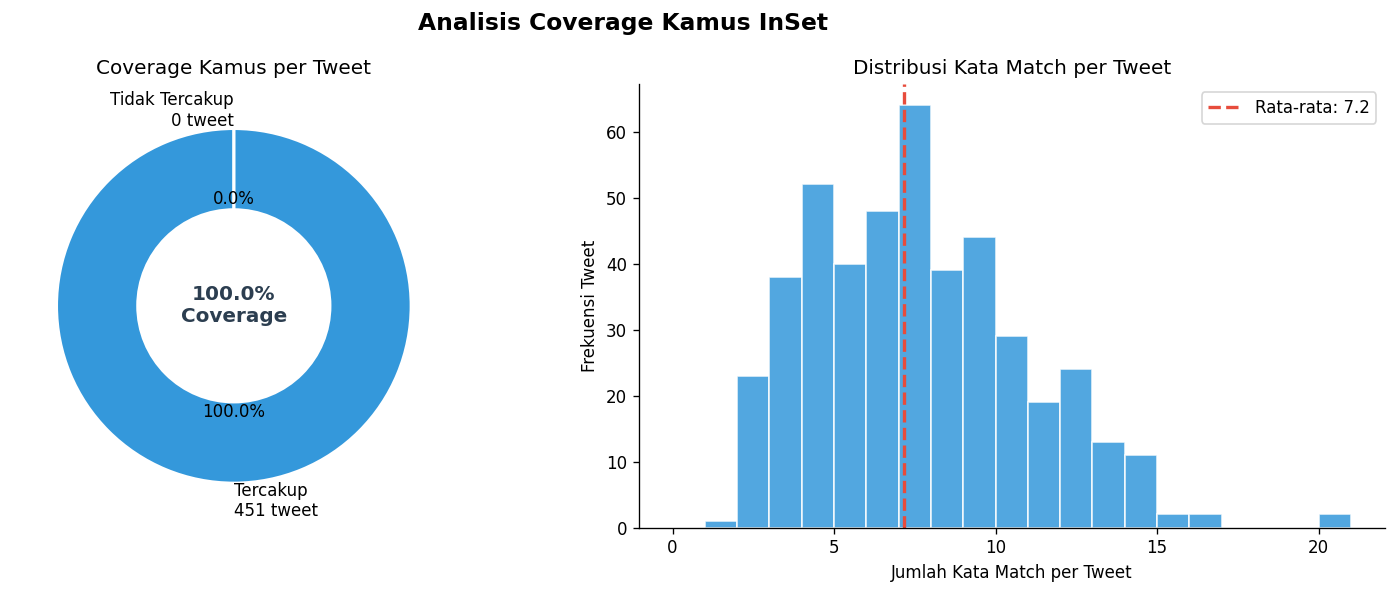

💾 Chart disimpan: Step_9B_coverage_kamus.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Coverage Kamus InSet', fontsize=14, fontweight='bold')

# ── Coverage donut ──
cov_data   = [tweet_covered, tweet_not_covered]
cov_labels = [f'Tercakup\n{tweet_covered} tweet', f'Tidak Tercakup\n{tweet_not_covered} tweet']
cov_colors = ['#3498db', '#ecf0f1']
wedges, texts, autotexts = axes[0].pie(
    cov_data, labels=cov_labels, autopct='%1.1f%%',
    colors=cov_colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
# Donut hole
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(centre_circle)
axes[0].text(0, 0, f'{coverage_rate:.1f}%\nCoverage', ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2c3e50')
axes[0].set_title('Coverage Kamus per Tweet', fontsize=12)

# ── Histogram n_match ──
max_match = min(df['n_match'].max(), 20)
bins = range(0, max_match + 2)
axes[1].hist(df['n_match'], bins=bins, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(avg_match, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Rata-rata: {avg_match:.1f}')
axes[1].set_xlabel('Jumlah Kata Match per Tweet')
axes[1].set_ylabel('Frekuensi Tweet')
axes[1].set_title('Distribusi Kata Match per Tweet', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Step_9B_coverage_kamus.png'), bbox_inches='tight', dpi=150)
plt.show()
print('💾 Chart disimpan: Step_9B_coverage_kamus.png')

## 11. Distribusi Skor Sentimen

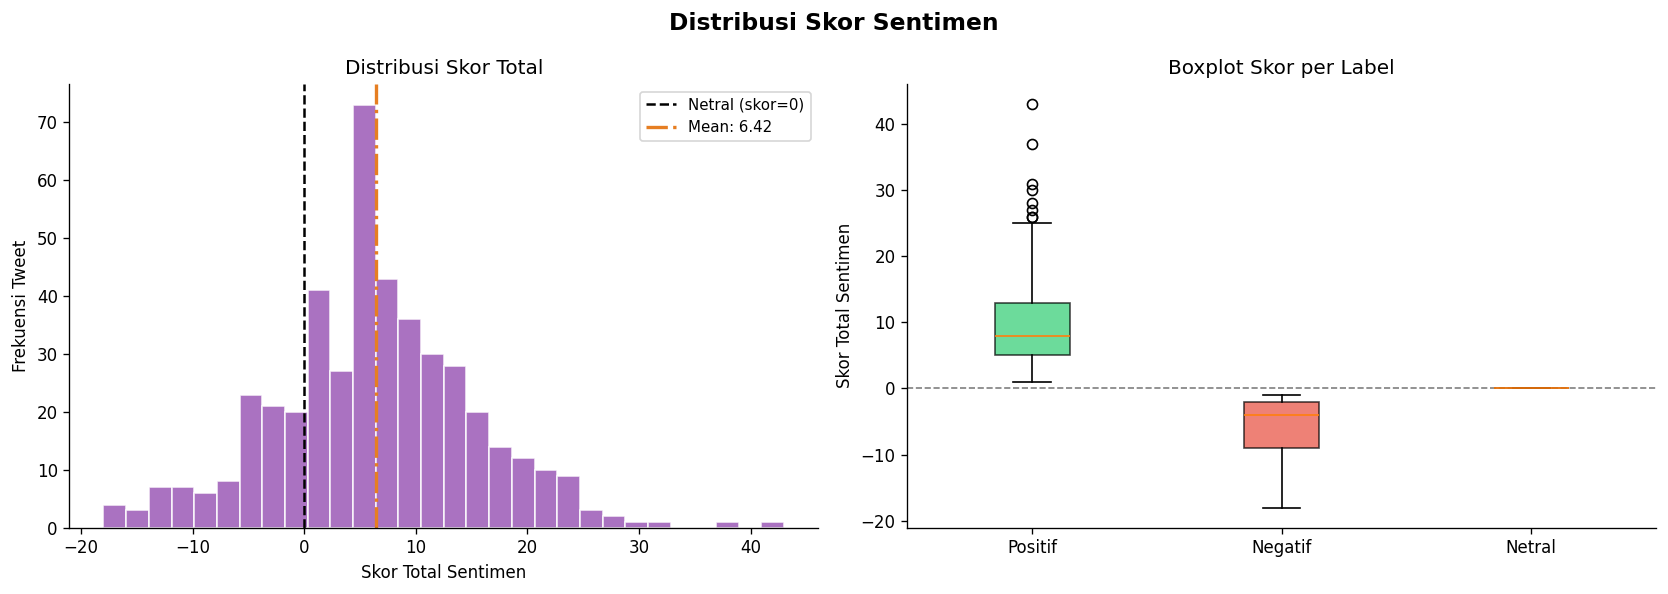

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Skor Sentimen', fontsize=14, fontweight='bold')

# ── Histogram skor total ──
axes[0].hist(df['skor_total'], bins=30, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Netral (skor=0)')
axes[0].axvline(df['skor_total'].mean(), color='#e67e22', linestyle='-.',
                linewidth=2, label=f'Mean: {df["skor_total"].mean():.2f}')
axes[0].set_xlabel('Skor Total Sentimen')
axes[0].set_ylabel('Frekuensi Tweet')
axes[0].set_title('Distribusi Skor Total')
axes[0].legend(fontsize=9)

# ── Boxplot per label ──
data_by_label = [df[df['sentimen'] == lbl]['skor_total'] for lbl in ['Positif', 'Negatif', 'Netral']]
bp = axes[1].boxplot(data_by_label, labels=['Positif', 'Negatif', 'Netral'],
                     patch_artist=True, notch=False)
for patch, lbl in zip(bp['boxes'], ['Positif', 'Negatif', 'Netral']):
    patch.set_facecolor(PALETTE[lbl])
    patch.set_alpha(0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('Skor Total Sentimen')
axes[1].set_title('Boxplot Skor per Label')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Step_9B_distribusi_skor.png'), bbox_inches='tight', dpi=150)
plt.show()

## 12. Inspeksi Sampel per Label

In [ ]:
SHOW_N = 5

def tampilkan_sampel(label: str, n: int = SHOW_N):
    print(f'\n{"="*60}')
    print(f'  Sampel Tweet — {label.upper()} (n={n})')
    print(f'{"="*60}')
    subset = df[df['sentimen'] == label].head(n)
    for idx, row in subset.iterrows():
        print(f'\n[Tweet #{idx+1}]  Skor: {row["skor_total"]:.1f}')
        print(f'  Tokens  : {", ".join(row["tokens"][:12])}...')
        print(f'  Match   : {[(k,v) for k,v in row["kata_match"]]}')


tampilkan_sampel('Positif')
tampilkan_sampel('Negatif')
tampilkan_sampel('Netral')


  Sampel Tweet — POSITIF (n=5)

[Tweet #1]  Skor: 3.0
  Tokens  : anggaran, segitu, sekolah, tambahan, orang, tua, program, makan, siang, gratis, mark, atas...
  Match   : [('segitu', -3.0), ('sekolah', 3.0), ('tambahan', 5.0), ('tua', -4.0), ('makan', 1.0), ('gratis', 4.0), ('atas', -4.0), ('aku', 2.0), ('gratis', 4.0), ('gabungan', -5.0)]

[Tweet #2]  Skor: 4.0
  Tokens  : keren, program, makan, siang, gratis, seperti, gini, pertumbuhan, perkembangan, anak, indonesia, fisik...
  Match   : [('makan', 1.0), ('gratis', 4.0), ('seperti', -1.0), ('perkembangan', -4.0), ('anak', -3.0), ('kemampuan', 4.0), ('mengikuti', 3.0)]

[Tweet #3]  Skor: 12.0
  Tokens  : prabowo, komitmen, nyata, makan, siang, gratis, bergizi, anakanak, sekolah...
  Match   : [('nyata', 4.0), ('makan', 1.0), ('gratis', 4.0), ('sekolah', 3.0)]

[Tweet #4]  Skor: 24.0
  Tokens  : program, prabowo, makan, gratis, kpd, pelajar, hamil, pelajar, juta, mari, hitung, biaya...
  Match   : [('makan', 1.0), ('gratis', 4.0), ('

## 13. Simpan Output CSV

In [ ]:
# Kolom yang disimpan ke output
output_cols = [
    'No', 'full_text', 'username',
    'tweet_normalized',
    'skor_total', 'skor_positif', 'skor_negatif',
    'n_match', 'n_total',
    'kata_match',
    'sentimen'
]

# Hanya sertakan kolom yang ada di dataframe
output_cols = [c for c in output_cols if c in df.columns]

df_out = df[output_cols].copy()
df_out['kata_match'] = df_out['kata_match'].apply(str)  # serialisasi list

df_out.to_csv(PATH_OUTPUT_CSV, index=False, encoding='utf-8-sig', sep=';')

print(f'✅ Output disimpan ke: {PATH_OUTPUT_CSV}')
print(f'   Total baris : {len(df_out)}')
print(f'   Kolom       : {df_out.columns.tolist()}')
print()
print('Preview output:')
df_out[['sentimen', 'skor_total', 'n_match']].value_counts().head(10)

✅ Output disimpan ke: /content/Step_9B_Hasil_Sentimen.csv
   Total baris : 451
   Kolom       : ['No', 'full_text', 'username', 'tweet_normalized', 'skor_total', 'skor_positif', 'skor_negatif', 'n_match', 'n_total', 'kata_match', 'sentimen']

Preview output:


sentimen  skor_total  n_match
Positif   5.0         2          23
          8.0         3          14
          5.0         4          10
          6.0         4           9
          2.0         3           7
          9.0         3           6
          5.0         6           6
          6.0         6           5
                      7           5
          12.0        4           5
Name: count, dtype: int64

## 14. Ringkasan Akhir

In [ ]:
print('┌' + '─'*52 + '┐')
print('│       RINGKASAN STEP 9B — LABELING SENTIMEN       │')
print('├' + '─'*52 + '┤')
print(f'│  Kamus InSet positif    : {len(pos_words):>6,} entri           │')
print(f'│  Kamus InSet negatif    : {len(neg_words):>6,} entri           │')
print(f'│  Total tweet dianalisis : {len(df):>6,}                 │')
print('├' + '─'*52 + '┤')

for lbl in ['Positif', 'Negatif', 'Netral']:
    n   = dist[lbl]
    pct = dist_pct[lbl]
    icon = '✅' if lbl == 'Positif' else ('❌' if lbl == 'Negatif' else '➖')
    print(f'│  {icon} {lbl:<10}          : {n:>5} tweet ({pct:>5.1f}%)    │')

print('├' + '─'*52 + '┤')
print(f'│  Coverage kamus         : {coverage_rate:>6.1f}%                │')
print(f'│  Rata-rata kata match   : {avg_match:>6.2f} per tweet          │')
print(f'│  Kata unik digunakan    : {len(all_matched_words):>6,}                 │')
print('└' + '─'*52 + '┘')
print()
print('📁 File output:')
print(f'   • {os.path.basename(PATH_OUTPUT_CSV)}')
print('   • Step_9B_distribusi_sentimen.png')
print('   • Step_9B_top_kata_sentimen.png')
print('   • Step_9B_wordcloud.png')
print('   • Step_9B_coverage_kamus.png')
print('   • Step_9B_distribusi_skor.png')

┌────────────────────────────────────────────────────┐
│       RINGKASAN STEP 9B — LABELING SENTIMEN       │
├────────────────────────────────────────────────────┤
│  Kamus InSet positif    :  3,053 entri           │
│  Kamus InSet negatif    :  6,018 entri           │
│  Total tweet dianalisis :    451                 │
├────────────────────────────────────────────────────┤
│  ✅ Positif             :   352 tweet ( 78.0%)    │
│  ❌ Negatif             :    89 tweet ( 19.7%)    │
│  ➖ Netral              :    10 tweet (  2.2%)    │
├────────────────────────────────────────────────────┤
│  Coverage kamus         :  100.0%                │
│  Rata-rata kata match   :   7.15 per tweet          │
│  Kata unik digunakan    :    638                 │
└────────────────────────────────────────────────────┘

📁 File output:
   • Step_9B_Hasil_Sentimen.csv
   • Step_9B_distribusi_sentimen.png
   • Step_9B_top_kata_sentimen.png
   • Step_9B_wordcloud.png
   • Step_9B_coverage_kamus.png
   • Step_9B

In [ ]:
from google.colab import files
files.download('Step_9B_Hasil_Sentimen.csv')
files.download('Step_9B_distribusi_sentimen.png')
files.download('Step_9B_top_kata_sentimen.png')
files.download('Step_9B_wordcloud.png')
files.download('Step_9B_coverage_kamus.png')
files.download('Step_9B_distribusi_skor.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>